<a href="https://colab.research.google.com/github/lexinejazly-asuncion/Sign-Language-Classification/blob/main/Sign_Language_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
!pip install pandas
!pip install pillow
!pip install kaggle
!pip install scikit-learn
!pip install torchvision

#**Load Data**

In [30]:
from pathlib import Path
import zipfile

dataset_folder = Path("dataset/SigNN Character Database")
zip_path = Path("dataset/asl-sign-language-pictures-minus-j-z.zip")

if not zip_path.exists():
    !kaggle datasets download -d signnteam/asl-sign-language-pictures-minus-j-z -p dataset
else:
    print("Zip file already downloaded.")

if not dataset_folder.exists():
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall("dataset")
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

Zip file already downloaded.
Dataset already extracted.


# **EDA**

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [32]:
data_path = Path("dataset/SigNN Character Database")

paths = [path.parts[-2:] for path in data_path.rglob("*.*")] #gives the class and image file name

sl_df = pd.DataFrame(data=paths, columns=["Class","Images"]) #create column names for dataframe
sl_df = sl_df.sort_values("Class",ascending=True)
sl_df.reset_index(drop=True, inplace=True)
sl_df.head()

,Class,Images
0,A,75.jpg
1,A,214.jpg
2,A,199.jpg
3,A,411.jpg
4,A,425.jpg


Total images in dataset: 8442
Total classes: 24

Total images per class:
{'B': 541, 'A': 539, 'E': 498, 'F': 420, 'C': 387, 'D': 379, 'O': 374, 'H': 364, 'I': 360, 'W': 347, 'L': 346, 'G': 345, 'V': 337, 'K': 319, 'Y': 318, 'S': 314, 'X': 310, 'T': 301, 'N': 293, 'R': 291, 'U': 286, 'M': 277, 'Q': 275, 'P': 221}


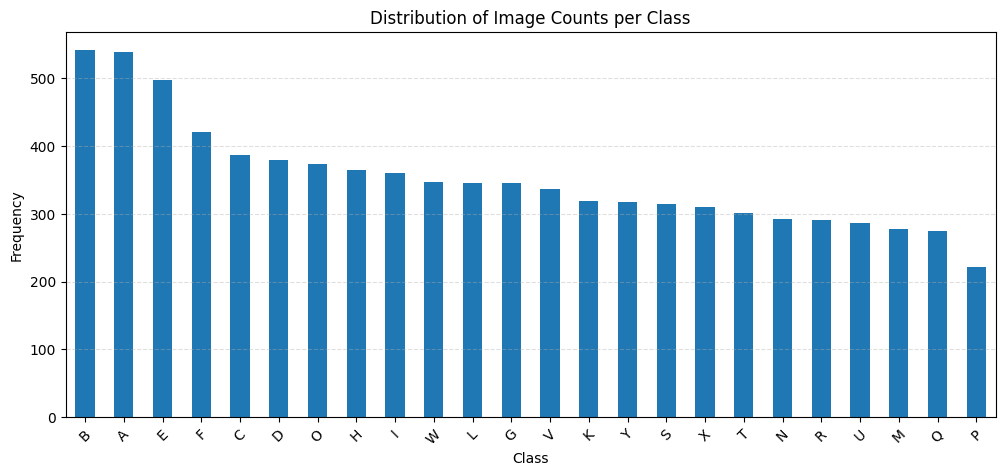

In [33]:
print(f"Total images in dataset: {len(sl_df)}")
print(f"Total classes: {sl_df['Class'].nunique()}")
print("\nTotal images per class:")

class_counts = sl_df["Class"].value_counts()
print(class_counts.to_dict())

class_counts.plot(kind="bar", figsize=(12,5))
plt.xticks(rotation=45)
plt.title('Distribution of Image Counts per Class')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.4)


In [34]:
from PIL import Image
import os

#finds dimensions of each image
def get_img_dim(x):
  img_path = os.path.join(data_path, x["Class"], x["Images"])
  with Image.open(img_path) as img:
    return img.size

#creates two new columns in df: width and height
sl_df[["Width", "Height"]] = sl_df.apply(get_img_dim, axis=1, result_type="expand")
sl_df.head()

,Class,Images,Width,Height
0,A,75.jpg,640,480
1,A,214.jpg,640,480
2,A,199.jpg,640,480
3,A,411.jpg,640,480
4,A,425.jpg,640,480


In [35]:
#finds the different dimensions of each class
img_sizes = sl_df.groupby('Class').apply(
    lambda x: x[['Width', 'Height']].drop_duplicates().apply(
        lambda x: f"{int(x['Width'])}x{int(x['Height'])}", axis=1).tolist(), include_groups=False
)

print(f"Image sizes per class: {img_sizes}")


Image sizes per class: Class
A              [640x480, 1920x1920]
B              [640x480, 1920x1920]
C              [1920x1920, 640x480]
D              [640x480, 1920x1920]
E              [1920x1920, 640x480]
F              [640x480, 1920x1920]
G              [640x480, 1920x1920]
H              [640x480, 1920x1920]
I              [640x480, 1920x1920]
K              [640x480, 1920x1920]
L              [640x480, 1920x1920]
M              [640x480, 1920x1920]
N    [640x480, 1920x1920, 1280x720]
O              [640x480, 1920x1920]
P              [640x480, 1920x1920]
Q    [640x480, 1280x720, 1920x1920]
R              [640x480, 1920x1920]
S    [640x480, 1280x720, 1920x1920]
T              [1920x1920, 640x480]
U              [640x480, 1920x1920]
V    [1280x720, 1920x1920, 640x480]
W    [640x480, 1920x1920, 1280x720]
X              [640x480, 1920x1920]
Y              [640x480, 1920x1920]
dtype: object


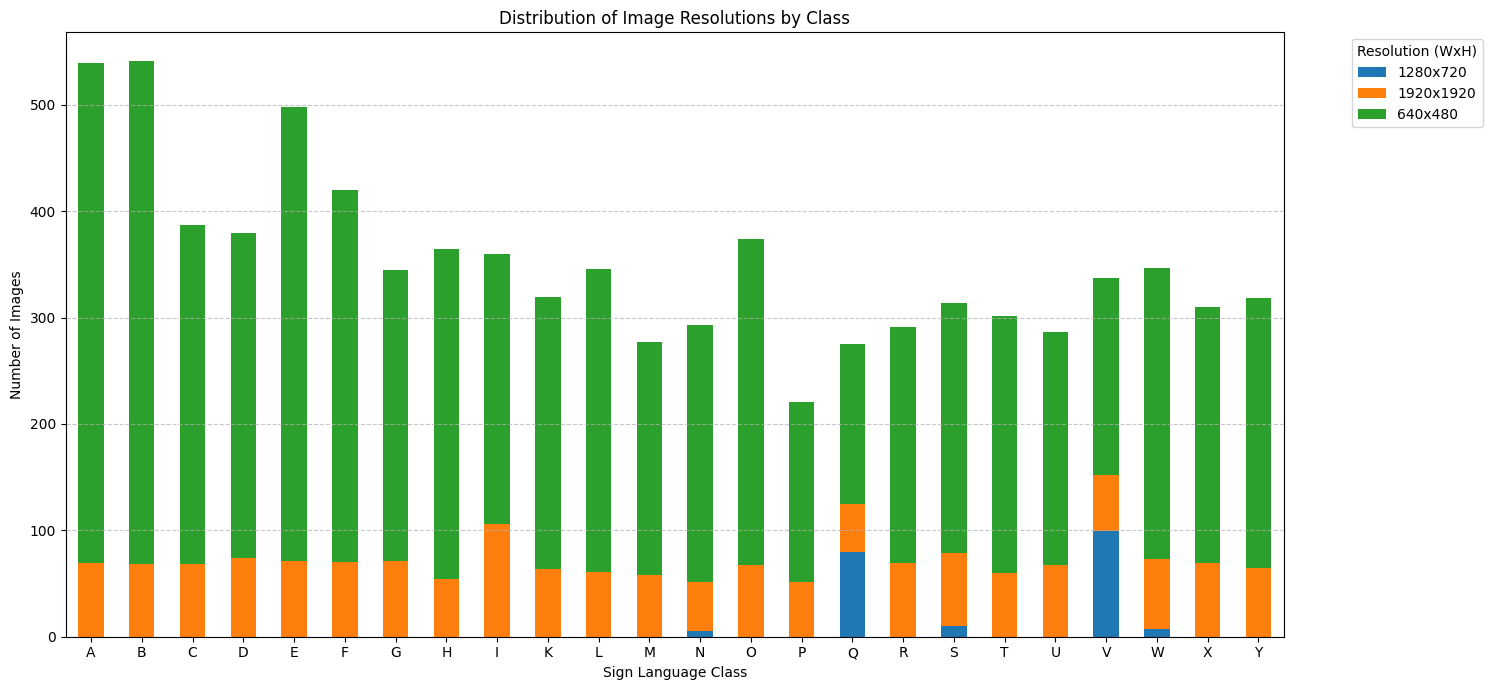

In [36]:
sl_df['Size'] = sl_df['Width'].astype(str) + 'x' + sl_df['Height'].astype(str)

size_pivot = sl_df.groupby(['Class', 'Size']).size().unstack(fill_value=0)

size_pivot.plot(kind='bar', stacked=True, figsize=(15, 7))

plt.title('Distribution of Image Resolutions by Class')
plt.xlabel('Sign Language Class')
plt.ylabel('Number of Images')
plt.legend(title='Resolution (WxH)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **Preprocessing**

In [37]:
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

In [38]:
#split data: 70% train, 10% validation, 20%test
temp, test_set = train_test_split(sl_df, test_size=0.2, stratify=sl_df["Class"], random_state=42)
train_set, val_set = train_test_split(temp, test_size=0.125, stratify=temp["Class"], random_state=42)

print("Training Set Distribution:")
print(train_set["Class"].value_counts())

print("\nValidation Set Distribution:")
print(val_set["Class"].value_counts())

print("\nTest Set Distribution:")
print(test_set["Class"].value_counts())

print("\nTrain Set Size:", len(train_set))
print("Validation Set Size:", len(val_set))
print("Test Set Size:", len(test_set))



Training Set Distribution:
Class
B    379
A    377
E    348
F    294
C    270
D    265
O    262
H    255
I    252
W    243
L    242
G    241
V    236
K    223
Y    222
S    220
X    217
T    211
N    205
R    204
U    200
M    194
Q    193
P    155
Name: count, dtype: int64

Validation Set Distribution:
Class
B    54
A    54
E    50
F    42
C    39
D    38
O    37
H    36
I    36
L    35
W    35
G    35
V    34
K    32
Y    32
X    31
S    31
T    30
R    29
N    29
U    29
M    28
Q    27
P    22
Name: count, dtype: int64

Test Set Distribution:
Class
A    108
B    108
E    100
F     84
C     78
D     76
O     75
H     73
I     72
L     69
W     69
G     69
V     67
Y     64
K     64
S     63
X     62
T     60
N     59
R     58
U     57
M     55
Q     55
P     44
Name: count, dtype: int64

Train Set Size: 5908
Validation Set Size: 845
Test Set Size: 1689


In [39]:
class ASLDataset(Dataset):
    def __init__(self, df, data_path, transform=None):
        self.df = df
        self.data_path = data_path
        self.transform = transform
        self.label_map = {label: i for i, label in enumerate(sorted(df['Class'].unique()))} #for label encoding

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.data_path, row["Class"], row["Images"])

        image = Image.open(img_path).convert("RGB") #transform image to color
        label = self.label_map[row["Class"]] #labels represented as ints

        if self.transform:
            image = self.transform(image) #apply the transformation

        return image, label

train_preprocess_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ToTensor(), #scale and reshape data to a tensor
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) #normalize to [-1,1]
])

val_test_preprocess_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(), #scale and reshape data to a tensor
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) #normalize to [-1,1]
])

In [40]:
#balanced undersampling, 150 each class
train_set_balanced = train_set.groupby("Class").sample(n=150, random_state=42).reset_index(drop=True)

train_dataset = ASLDataset(train_set_balanced, data_path, transform=train_preprocess_pipeline) #preprocess data
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) #loads data into the model

val_dataset = ASLDataset(val_set, data_path, transform=val_test_preprocess_pipeline)
val_loader = DataLoader(val_dataset, batch_size=32) #shuffle=False

test_dataset = ASLDataset(test_set, data_path, transform=val_test_preprocess_pipeline)
test_loader = DataLoader(test_dataset, batch_size=32) #shuffle=False

# **Training**

## **Initial Custom CNN Model**



In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report

test_dataset.label_map = train_dataset.label_map

class ASLCNN(nn.Module):
    def __init__(self, num_classes=24):
        super(ASLCNN, self).__init__()
        self.features = nn.Sequential(
            #convolutional layers
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

####**Experiment \#1**

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ASLCNN(num_classes=24).to(device)

print("Initialized on: ", device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Initialized on:  cuda


In [43]:
#Train and Validation Set

import time

start = time.time()

epochs = 5

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(epochs):
    #test
    model.train()
    running_train_loss = 0

    train_preds = []
    train_labels = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    #validation
    model.eval()
    running_val_loss = 0
    correct = 0
    total = 0

    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    #epoch metrics: train loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = accuracy_score(train_labels, train_preds)


    #epoch metrics: validation loss and accuracy
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = accuracy_score(val_labels, val_preds)

    #store metrics
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"TRAIN Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f}")
    print(f"VALIDATION Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}")


end = time.time()

print(f"Execution time: {end - start:.2f} seconds")

Epoch [1/5]
TRAIN Loss: 0.0850, Acc: 0.2325
VALIDATION Loss: 0.0615, Acc: 0.4580
Epoch [2/5]
TRAIN Loss: 0.0548, Acc: 0.4697
VALIDATION Loss: 0.0434, Acc: 0.5893
Epoch [3/5]
TRAIN Loss: 0.0403, Acc: 0.6025
VALIDATION Loss: 0.0370, Acc: 0.6580
Epoch [4/5]
TRAIN Loss: 0.0343, Acc: 0.6631
VALIDATION Loss: 0.0300, Acc: 0.7290
Epoch [5/5]
TRAIN Loss: 0.0286, Acc: 0.7136
VALIDATION Loss: 0.0284, Acc: 0.7574
Execution time: 341.45 seconds


####**Experiment \#2: Increase the number of epochs to 10**


In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ASLCNN(num_classes=24).to(device)

print("Initialized on: ", device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Initialized on:  cuda


In [45]:
#Train and Validation Set

import time

start = time.time()

epochs = 10

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(epochs):
    #test
    model.train()
    running_train_loss = 0

    train_preds = []
    train_labels = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    #validation
    model.eval()
    running_val_loss = 0
    correct = 0
    total = 0

    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    #epoch metrics: train loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = accuracy_score(train_labels, train_preds)


    #epoch metrics: validation loss and accuracy
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = accuracy_score(val_labels, val_preds)

    #store metrics
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"TRAIN Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f}")
    print(f"VALIDATION Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}")

end = time.time()

print(f"Execution time: {end - start:.2f} seconds")

Epoch [1/10]
TRAIN Loss: 0.0834, Acc: 0.2256
VALIDATION Loss: 0.0592, Acc: 0.4746
Epoch [2/10]
TRAIN Loss: 0.0513, Acc: 0.5142
VALIDATION Loss: 0.0380, Acc: 0.6580
Epoch [3/10]
TRAIN Loss: 0.0374, Acc: 0.6400
VALIDATION Loss: 0.0313, Acc: 0.7160
Epoch [4/10]
TRAIN Loss: 0.0298, Acc: 0.7058
VALIDATION Loss: 0.0283, Acc: 0.7491
Epoch [5/10]
TRAIN Loss: 0.0227, Acc: 0.7706
VALIDATION Loss: 0.0244, Acc: 0.7858
Epoch [6/10]
TRAIN Loss: 0.0202, Acc: 0.7953
VALIDATION Loss: 0.0220, Acc: 0.8095
Epoch [7/10]
TRAIN Loss: 0.0169, Acc: 0.8278
VALIDATION Loss: 0.0216, Acc: 0.8260
Epoch [8/10]
TRAIN Loss: 0.0142, Acc: 0.8572
VALIDATION Loss: 0.0221, Acc: 0.8320
Epoch [9/10]
TRAIN Loss: 0.0128, Acc: 0.8703
VALIDATION Loss: 0.0200, Acc: 0.8367
Epoch [10/10]
TRAIN Loss: 0.0112, Acc: 0.8831
VALIDATION Loss: 0.0193, Acc: 0.8509
Execution time: 657.40 seconds


####**Experiment \#3: Reduce number of epochs to 8, Add a 4th Layer**


In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report

test_dataset.label_map = train_dataset.label_map

class ASLCNN(nn.Module):
    def __init__(self, num_classes=24):
        super(ASLCNN, self).__init__()
        self.features = nn.Sequential(
            #convolutional layers
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ASLCNN(num_classes=24).to(device)

print("Initialized on: ", device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Initialized on:  cuda


In [48]:
#Train and Validation Set

import time

start = time.time()

epochs = 8

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(epochs):
    #test
    model.train()
    running_train_loss = 0

    train_preds = []
    train_labels = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    #validation
    model.eval()
    running_val_loss = 0
    correct = 0
    total = 0

    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    #epoch metrics: train loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = accuracy_score(train_labels, train_preds)


    #epoch metrics: validation loss and accuracy
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = accuracy_score(val_labels, val_preds)

    #store metrics
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"TRAIN Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f}")
    print(f"VALIDATIONLoss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}")


end = time.time()

print(f"Execution time: {end - start:.2f} seconds")

KeyboardInterrupt: 

#**ADD DATA VISUALIZATION FOR TRAINING/VALIDATION LOSS & ACCURACY**

## **Custom CNN Model Evaluation**

In [49]:
#Test Set
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

        test_acc = accuracy_score(test_labels, test_preds)
        test_precision = precision_score(test_labels, test_preds, average='weighted')
        test_recall = recall_score(test_labels, test_preds, average='weighted')
        test_f1 = f1_score(test_labels, test_preds, average='weighted')

print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")

print(classification_report(test_labels, test_preds, target_names=list(train_dataset.label_map.keys())))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

KeyboardInterrupt: 

#**ADD DATA VISUALIZATION FOR CONFUSION MATRIX, SAMPLE PREDICTIONS FOR BEST CUSTOM MODEL**

### **ResNet Pre-trained CNN Model**

#**ADD VALIDATION SET, FINE-TUNED RESNET**

In [55]:
from torchvision import models, transforms
import torch
import torch.nn as nn
import torch.optim as optim
import time
from sklearn.metrics import accuracy_score


# ResNet preprocessing
resnet_preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#load datasets with the ResNet preprocessing

train_dataset = ASLDataset(train_set, data_path, transform=resnet_preprocess)
val_dataset = ASLDataset(val_set, data_path, transform=resnet_preprocess)
test_dataset = ASLDataset(test_set, data_path, transform=resnet_preprocess)

# make sure val and test use same label mapping as train
val_dataset.label_map = train_dataset.label_map
test_dataset.label_map = train_dataset.label_map

# load data in batches
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


model = models.resnet18(pretrained=True)

# freeze all layers
for param in model.parameters():
    param.requires_grad = False

model = models.resnet18(pretrained=True)

#swapping out the last layer to create 24 classes
model.fc = nn.Linear(model.fc.in_features, 24)

#use GPU else CPU
model = model.to(device)

#loss function
criterion = nn.CrossEntropyLoss()
#passing only the top last layer
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


epochs = 5
train_losses_fc = []
val_losses_fc = []
val_accuracies_fc = []
start = time.time()
print("Regular ResNet")


#begin training and validation

for epoch in range(epochs):
    model.train()
    running_train_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
    model.eval()
    running_val_loss = 0
    val_preds = []
    val_labels = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = accuracy_score(val_labels, val_preds)
    train_losses_fc.append(epoch_train_loss)
    val_losses_fc.append(epoch_val_loss)
    val_accuracies_fc.append(epoch_val_acc)
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {epoch_train_loss:.4f}")
    print(f"Validation Loss: {epoch_val_loss:.4f}, Validation Accuracy: {epoch_val_acc:.4f}")
end = time.time()

print(f"ResNet FC only training time: {end - start:.2f} seconds")

#saved to draw the confusion matrix
model_fc = model

model = models.resnet18(pretrained=True)

#had to unfreeze layer4 to get better performance, otherwise the model was underfitting was
#getting around 80 %accuracy but after unfreezing layer4, accuracy jumped to around 97%
for param in model.layer4.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, 24)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {"params": model.layer4.parameters(), "lr": 0.0001},
    {"params": model.fc.parameters(), "lr": 0.001}
])
epochs = 5

train_losses = []
val_losses = []
val_accuracies = []

start = time.time()
print("Fine Tuned ResNet")

for epoch in range(epochs):
    model.train()
    running_train_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    model.eval()
    running_val_loss = 0
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = accuracy_score(val_labels, val_preds)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {epoch_train_loss:.4f}")
    print(f"Validation Loss: {epoch_val_loss:.4f}, Validation Accuracy: {epoch_val_acc:.4f}")


end = time.time()

print(f"ResNet training time: {end - start:.2f} seconds")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Regular ResNet
Epoch 1/5
Train Loss: 2.2620
Validation Loss: 1.5719, Validation Accuracy: 0.6402
Epoch 2/5
Train Loss: 1.3611
Validation Loss: 1.0956, Validation Accuracy: 0.7657
Epoch 3/5
Train Loss: 1.0372
Validation Loss: 0.8807, Validation Accuracy: 0.8118
Epoch 4/5
Train Loss: 0.8460
Validation Loss: 0.7479, Validation Accuracy: 0.8308
Epoch 5/5
Train Loss: 0.7258
Validation Loss: 0.6612, Validation Accuracy: 0.8592
ResNet FC only training time: 476.78 seconds


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Fine Tuned ResNet
Epoch 1/5
Train Loss: 0.8304
Validation Loss: 0.1317, Validation Accuracy: 0.9609
Epoch 2/5
Train Loss: 0.0639
Validation Loss: 0.0655, Validation Accuracy: 0.9834
Epoch 3/5
Train Loss: 0.0226
Validation Loss: 0.0517, Validation Accuracy: 0.9834
Epoch 4/5
Train Loss: 0.0169
Validation Loss: 0.0444, Validation Accuracy: 0.9858
Epoch 5/5
Train Loss: 0.0109
Validation Loss: 0.0422, Validation Accuracy: 0.9870
ResNet training time: 516.16 seconds


In [56]:

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="weighted")

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")


Test Accuracy: 0.9816
Weighted F1 Score: 0.9817


Test Accuracy: 0.8603
Weighted F1 Score: 0.8611


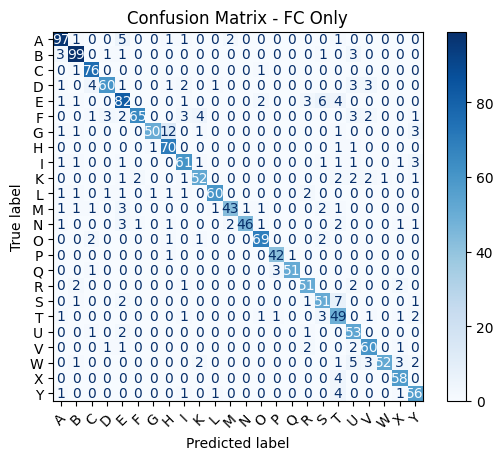

Test Accuracy: 0.9816
Weighted F1 Score: 0.9817


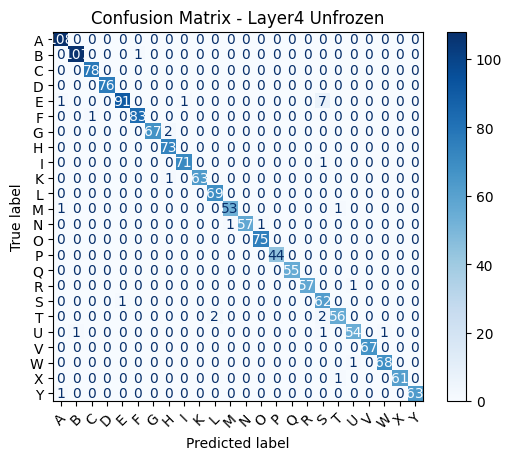

In [57]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# FC only
model_fc.eval()
all_preds_fc = []
all_labels_fc = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_fc(images)
        _, preds = torch.max(outputs, 1)
        all_preds_fc.extend(preds.cpu().numpy())
        all_labels_fc.extend(labels.cpu().numpy())
accuracy = accuracy_score(all_labels_fc, all_preds_fc)
f1 = f1_score(all_labels_fc, all_preds_fc, average="weighted")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")
class_names = [k for k, v in sorted(test_dataset.label_map.items(), key=lambda x: x[1])]
cm = confusion_matrix(all_labels_fc, all_preds_fc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - FC Only")
plt.show()

# Layer4 unfrozen
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="weighted")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Layer4 Unfrozen")
plt.show()

In [58]:
results = pd.DataFrame({
    "Model": ["Custom CNN", "Regular ResNet18", "Fine-Tuned ResNet18"],
    "Accuracy":  [0.8093, 0.7857, 0.9698],
    "Precision": [0.8093, 0.8100, 0.9711],
    "Recall":    [0.7916, 0.7857, 0.9698],
    "F1 Score":  [0.7934, 0.7874, 0.9699],
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Custom CNN,0.8093,0.8093,0.7916,0.7934
1,Regular ResNet18,0.7857,0.8100,0.7857,0.7874
2,Fine-Tuned ResNet18,0.9698,0.9711,0.9698,0.9699
